In [1]:
!pip install sentence-transformers scikit-learn pandas joblib matplotlib


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import matplotlib.pyplot as plt
import random

/home/regularpooria/Projects/WildCode/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ---------- CONFIG ----------
CSV_PATH = "labeled_wildchat_expertise.csv"   # your labeled CSV (must have 'init_message' and 'label')
EMBED_MODEL_NAME = "all-MiniLM-L12-v2"  # MiniLM v12
RANDOM_SEED = 42
TEST_SIZE = 0.2
CLASSIFIER_OUTPUT = "minilm12_logreg.joblib"
SCALER_OUTPUT = "minilm12_scaler.joblib"  # optional if you want scaler separate
# ----------------------------

In [4]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [5]:
# 1) Load data
df = pd.read_csv(CSV_PATH)
# Keep only valid labels (defensive)
valid_labels = {"beginner", "intermediate", "expert"}
df = df[df["init_label"].isin(valid_labels)].reset_index(drop=True)
df = df.groupby("init_label").apply(lambda x: x.sample(n=min(300, len(x)), random_state=42))
df = df.reset_index(drop=True)

print("Loaded", len(df), "rows with labels:", df["init_label"].value_counts().to_dict())

Loaded 900 rows with labels: {'beginner': 300, 'expert': 300, 'intermediate': 300}


/tmp/ipykernel_85758/3816843700.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("init_label").apply(lambda x: x.sample(n=min(300, len(x)), random_state=42))


In [6]:
# 2) Prepare text inputs
# Concatenate code + text if you have multiple columns; here we assume init_message contains both.
texts = df["init_message"].astype(str).tolist()
labels = df["init_label"].astype(str).tolist()

In [7]:
df[df["init_label"] == "expert"]["init_message"].sample(10)

503    Hi ChatGPT, I want you to act as an expect in ...
566    code:\nimport cv2\nfrom filterpy.kalman import...
452    InstagramのプロアカウントとInstagram graph API(version....
309    Есть ли замечания для этого кода:\n#include <c...
533    USB signalling and transceiver simulation matl...
526    write a s-order Markov chain for numerical seq...
496    Script for me a advanced momentum system in a ...
409    for the below code, add the followinfg things\...
305    code:\nimport cv2\nimport numpy as np\nimport ...
475    act as a python expert programmer, I will ask ...
Name: init_message, dtype: object

In [8]:

# 3) Compute embeddings with sentence-transformers
print("Loading embedding model:", EMBED_MODEL_NAME)
embedder = SentenceTransformer(EMBED_MODEL_NAME)

Loading embedding model: all-MiniLM-L12-v2


In [9]:
embeddings = embedder.encode(texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
print("Embeddings shape:", embeddings.shape)  # (N, dim)

Batches: 100%|██████████| 15/15 [00:15<00:00,  1.06s/it]

Embeddings shape: (900, 384)


In [10]:
# 4) Train / test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=labels
)
print("Train size:", len(y_train), "Test size:", len(y_test))

Train size: 720 Test size: 180


In [11]:
# 5) Build a small pipeline: scaler (optional) + logistic regression
# Note: MiniLM embeddings are already normalized-ish, but scaling can help some classifiers.
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    # Use balanced class_weight to help rare classes if needed
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED))
])

In [12]:

print("Training classifier...")
pipeline.fit(X_train, y_train)

Training classifier...


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [13]:

# 6) Evaluate
y_pred = pipeline.predict(X_test)
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=3))



Classification report:

              precision    recall  f1-score   support

    beginner      0.712     0.617     0.661        60
      expert      0.701     0.783     0.740        60
intermediate      0.525     0.533     0.529        60

    accuracy                          0.644       180
   macro avg      0.646     0.644     0.643       180
weighted avg      0.646     0.644     0.643       180



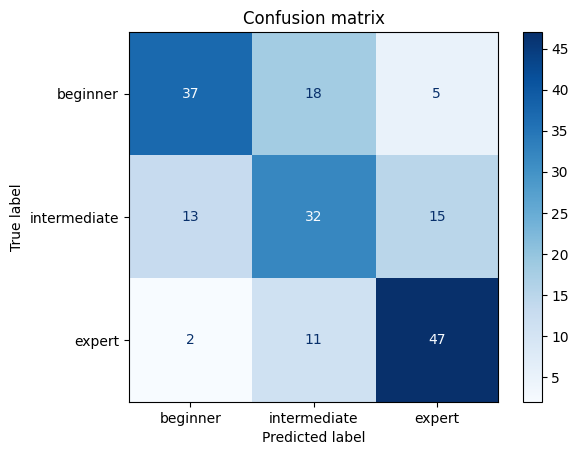

In [14]:
# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred, labels=["beginner", "intermediate", "expert"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["beginner", "intermediate", "expert"])
disp.plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()


In [15]:
# 7) Save model pipeline
joblib.dump(pipeline, CLASSIFIER_OUTPUT)
print("Saved classifier pipeline to", CLASSIFIER_OUTPUT)

Saved classifier pipeline to minilm12_logreg.joblib


In [16]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

In [17]:
EPOCHS = 50
LR = 1e-3
BATCH_SIZE = 8

In [18]:
torch.manual_seed(RANDOM_SEED)

In [19]:
le = LabelEncoder()
labels = le.fit_transform(df["init_label"])  # beginner=0, expert=1, intermediate=2 (order may vary)
num_classes = len(le.classes_)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=labels
)


In [21]:
# 5) PyTorch Dataset
class EmbedDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = EmbedDataset(X_train, y_train)
test_ds = EmbedDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [22]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

In [23]:
input_dim = embeddings.shape[1]
model = MLPClassifier(input_dim, num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


In [25]:
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")


Epoch 1/50, Loss: 1.0802
Epoch 2/50, Loss: 0.7933
Epoch 3/50, Loss: 0.5733
Epoch 4/50, Loss: 0.4471
Epoch 5/50, Loss: 0.3614
Epoch 6/50, Loss: 0.2730
Epoch 7/50, Loss: 0.1850
Epoch 8/50, Loss: 0.1369
Epoch 9/50, Loss: 0.1266
Epoch 10/50, Loss: 0.0891
Epoch 11/50, Loss: 0.0731
Epoch 12/50, Loss: 0.0724
Epoch 13/50, Loss: 0.0677
Epoch 14/50, Loss: 0.0417
Epoch 15/50, Loss: 0.0622
Epoch 16/50, Loss: 0.0460
Epoch 17/50, Loss: 0.0524
Epoch 18/50, Loss: 0.0358
Epoch 19/50, Loss: 0.0396
Epoch 20/50, Loss: 0.0319
Epoch 21/50, Loss: 0.0232
Epoch 22/50, Loss: 0.0110
Epoch 23/50, Loss: 0.0185
Epoch 24/50, Loss: 0.0348
Epoch 25/50, Loss: 0.0282
Epoch 26/50, Loss: 0.0282
Epoch 27/50, Loss: 0.0135
Epoch 28/50, Loss: 0.0258
Epoch 29/50, Loss: 0.0194
Epoch 30/50, Loss: 0.0505
Epoch 31/50, Loss: 0.0459
Epoch 32/50, Loss: 0.0809
Epoch 33/50, Loss: 0.0606
Epoch 34/50, Loss: 0.0372
Epoch 35/50, Loss: 0.0291
Epoch 36/50, Loss: 0.0133
Epoch 37/50, Loss: 0.0326
Epoch 38/50, Loss: 0.0333
Epoch 39/50, Loss: 0.

In [26]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

In [27]:

print("\nClassification report:\n")
print(classification_report(all_labels, all_preds, target_names=le.classes_))



Classification report:

              precision    recall  f1-score   support

    beginner       0.77      0.60      0.67        60
      expert       0.68      0.80      0.73        60
intermediate       0.55      0.57      0.56        60

    accuracy                           0.66       180
   macro avg       0.66      0.66      0.65       180
weighted avg       0.66      0.66      0.65       180



In [28]:
le.classes_

array(['beginner', 'expert', 'intermediate'], dtype=object)

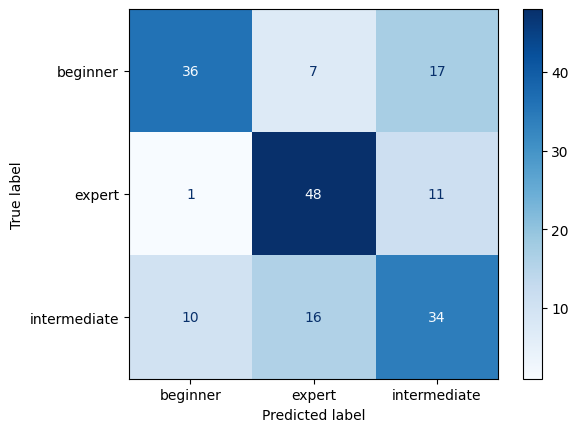

In [29]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.show()


In [30]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType

In [66]:
# --- Map labels to integers first ---
class_to_int = {"beginner": 0, "intermediate": 1, "expert": 2}
df["label"] = df["init_label"].map(class_to_int)

# --- Train / val split using integer labels ---
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["init_message"].tolist(),
    df["label"].tolist(),      # <-- use numeric labels here
    test_size=0.2,
    stratify=df["label"],      # <-- stratify by integer labels
    random_state=42
)


In [67]:
# --- Tokenizer ---
model_name = "sentence-transformers/all-MiniLM-L12-v2"  # MiniLM v12
tokenizer = AutoTokenizer.from_pretrained(model_name)
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=256)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=256)


In [75]:
class ChatDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels  # integers: 0,1,2
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k,v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)  # <-- MUST be 'labels'
        return item


In [76]:

train_dataset = ChatDataset(train_encodings, train_labels)
val_dataset = ChatDataset(val_encodings, val_labels)


In [77]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sentence-transformers/all-MiniLM-L12-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [78]:

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "key", "value"]
)


In [79]:
model = get_peft_model(model, lora_config)

In [ ]:
# --- Training ---
training_args = TrainingArguments(
    output_dir="./lora_classifier",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-4,
    logging_dir="./logs",
    logging_steps=10,
    save_total_limit=2,
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=lambda p: {"accuracy": (p.predictions.argmax(-1) == p.label_ids).mean()}
)

/tmp/ipykernel_85758/1889691651.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [81]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.094700,1.092365,0.438889
2,1.084400,1.084675,0.600000
3,1.074900,1.069356,0.616667


/home/regularpooria/Projects/WildCode/venv/lib64/python3.13/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/regularpooria/Projects/WildCode/venv/lib64/python3.13/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/regularpooria/Projects/WildCode/venv/lib64/python3.13/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


KeyboardInterrupt: 